# 🎬 SentIA — Sistema de Reconocimiento Emocional de Audiencias
## Procesamiento de Imágenes · Práctica Profesionalizante · TSCDIA 2024

**Integrantes:** Zucaria, Nahir · Santarena, Florencia · Cortés, Camila · Cabrera, Juan  
**Docente:** Carlos Ignacio Charletti  
**Dataset:** Facial Emotions Recognition Dataset — Nabil Sherif (Kaggle, Apache 2.0)  

---

### Descripción del proyecto
SentIA es un sistema de visión artificial que analiza las expresiones faciales de espectadores
durante funciones de avant-première cinematográfica. Utiliza Transfer Learning con ResNet50
para clasificar emociones en tiempo real, generando métricas objetivas sobre el impacto
emocional de cada escena.

### Estructura del notebook
| Sección | Contenido |
|---|---|
| 0 | Autenticación y descarga del dataset desde Kaggle |
| 1 | Preprocesamiento de imágenes |
| 2-3 | Data augmentation y arquitectura del modelo (ResNet50) |
| 4 | Callbacks y entrenamiento |
| 5 | Evaluación y métricas finales |
| 6 | Script de inferencia (predicción sobre nuevas imágenes) |
| 7 | Demostración interactiva |

Autenticando y descargando datos...
Dataset URL: https://www.kaggle.com/datasets/nabilsherif/facial-emotions-recognition-dataset
License(s): apache-2.0
100% 61.3M/61.3M [00:00<00:00, 75.3MB/s]

Dataset cargado con éxito!

Procesando las imágenes...
La carpeta 'surprised' no existe en la ruta.
Cargando clase: happy
Cargando clase: fear
Cargando clase: sad

--- RESUMEN DEL DATASET ---
Total de imágenes listas para la red: 16148
Cantidad de clases reales detectadas: 3
Emociones que se van a entrenar: ['happy', 'fear', 'sad']
Total de imágenes listas: 16148


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Entrenando la red...
Epoch 1/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 81s 170ms/step - accuracy: 0.5307 - loss: 0.9749 - val_accuracy: 0.6362 - val_loss: 0.8132
Epoch 2/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.5960 - loss: 0.8693 - val_accuracy: 0.6656 - val_loss: 0.7538
Epoch 3/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.6084 - loss: 0.8471 - val_accuracy: 0.6728 - val_loss: 0.7421
Epoch 4/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.6228 - loss: 0.8188 - val_accuracy: 0.6749 - val_loss: 0.7331
Epoch 5/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.6365 - loss: 0.8062 - val_accuracy: 0.6799 - val_loss: 0.7229
Epoch 6/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 73s 182ms/step - accuracy: 0.6385 - loss: 0.7972 - val_accuracy: 0.6876 - val_loss: 0.7174
Epoch 7/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.6394 - loss: 0.7918 - val_accuracy: 0.6916 - val_loss: 0.7119
Epoch 8/30

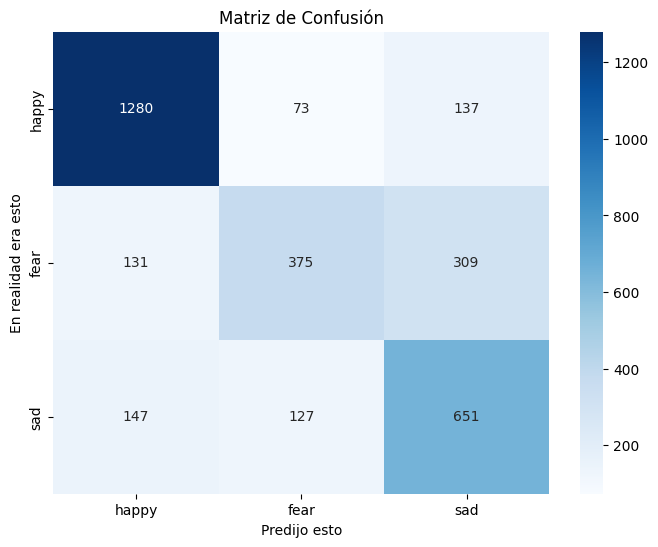

In [ ]:
# ============================================================
# IMPORTACIONES
# Cargamos todas las librerías necesarias para el proyecto:
#   - os, cv2: manejo de archivos e imágenes
#   - numpy: operaciones matemáticas sobre arrays
#   - matplotlib, seaborn: visualizaciones y gráficos
#   - tensorflow/keras: construcción y entrenamiento del modelo
#   - ResNet50: arquitectura preentrenada para Transfer Learning
#   - sklearn: partición del dataset y métricas de evaluación
# ============================================================

import os
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import userdata

# ============================================================
# SECCIÓN 0 — DESCARGA DEL DATASET DESDE KAGGLE
# Autenticamos con las credenciales de Kaggle almacenadas
# en los 'Secrets' de Google Colab (KAGGLE_USERNAME y KAGGLE_KEY).
# Esto evita exponer las credenciales directamente en el código.
# Dataset: nabilsherif/facial-emotions-recognition-dataset
# Licencia: Apache 2.0
# ==========================================

print("Autenticando y descargando datos...")
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Descargo y descomprimo
!kaggle datasets download -d nabilsherif/facial-emotions-recognition-dataset
!unzip -o -q facial-emotions-recognition-dataset.zip -d dataset_sent_ia
print("Dataset cargado con éxito!")

# ==========================================
# 1. PREPROCESAMIENTO DE LAS IMÁGENES
# ==========================================
ruta_dataset = '/content/dataset_sent_ia/facial emotion recognition/train'

# Estas son las que querés buscar originalmente
clases_propuestas = ['surprised', 'happy', 'fear', 'sad']

X_data = []
y_labels = []
clases_sent_ia = [] # guarda las que existen en el disco

print("\nProcesando las imágenes...")
for emocion in clases_propuestas:
    ruta_emocion = os.path.join(ruta_dataset, emocion)

    if os.path.exists(ruta_emocion):
        print(f"Cargando clase: {emocion}")
        clases_sent_ia.append(emocion) # La registramos como clase válida
        label_idx = len(clases_sent_ia) - 1 # Asigna índices limpios y secuenciales (0, 1, 2...)

        for archivo in os.listdir(ruta_emocion):
            ruta_img = os.path.join(ruta_emocion, archivo)
            img = cv2.imread(ruta_img)

            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized = cv2.resize(img_rgb, (224, 224))
                X_data.append(resized)
                y_labels.append(label_idx)
    else:
        # si la carpeta no existe, te avisa acá abajo en vez de fallar callada
        print(f"La carpeta '{emocion}' no existe en la ruta.")

# Convierto las listas a arrays de NumPy
X_data = np.array(X_data)
y_labels = np.array(y_labels)

# Separo 20% para validar después
X_train, X_val, y_train, y_val = train_test_split(X_data, y_labels, test_size=0.2)

print("\n--- RESUMEN DEL DATASET ---")
print(f"Total de imágenes listas para la red: {X_data.shape[0]}")
print(f"Cantidad de clases reales detectadas: {len(clases_sent_ia)}")
print(f"Emociones que se van a entrenar: {clases_sent_ia}")

# Convierto las listas a arrays de NumPy (Se guardan como uint8 automáticamente)
X_data = np.array(X_data)
y_labels = np.array(y_labels)



# Separo 20% para validar después (X_train y X_val ahora son livianos)
X_train, X_val, y_train, y_val = train_test_split(X_data, y_labels, test_size=0.2)
print(f"Total de imágenes listas: {X_data.shape[0]}")


# ==========================================
# 2 y 3. DATA AUGMENTATION Y RED NEURONAL
# ==========================================
# IMPORTANTE: Importamos el preprocesador nativo de ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Expando mi dataset con giros y espejados aleatorios
data_augmentation = models.Sequential([

    layers.Lambda(preprocess_input, input_shape=(224, 224, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
])

# Cargo ResNet50 sin la última capa (Transfer Learning)
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnet.trainable = False # Congelo los pesos

# Armo la arquitectura final
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_resnet(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(clases_sent_ia), activation='softmax')(x)

modelo = models.Model(inputs, outputs)

# para evitar que caiga rápido en mínimos locales perezosos.
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 4. CALLBACKS Y ENTRENAMIENTO
# ==========================================
# Freno el entrenamiento si no mejora y guardo el mejor modelo
mis_callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint(filepath='mi_mejor_modelo.keras', save_best_only=True)
]

print("\nEntrenando la red...")
historia = modelo.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=mis_callbacks
)


# ==========================================
# 5. EVALUACIÓN Y MÉTRICAS FINALES
# ==========================================
print("\nEvaluando resultados...")
loss_prueba, exactitud_prueba = modelo.evaluate(X_val, y_val)

predicciones_brutas = modelo.predict(X_val)
y_pred = np.argmax(predicciones_brutas, axis=1)

print("\n--- Reporte de Métricas ---")
print(classification_report(y_val, y_pred, target_names=clases_sent_ia))

# Matriz de Confusión para ver en qué emociones se equivoca
matriz = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=clases_sent_ia, yticklabels=clases_sent_ia)
plt.xlabel('Predijo esto')
plt.ylabel('En realidad era esto')
plt.title('Matriz de Confusión')
plt.show()


# ==========================================
# 6. SCRIPT DE PREDICCIÓN (INFERENCIA)
# ==========================================
def clasificar_emocion(ruta_nueva_imagen):
    img_nueva = cv2.imread(ruta_nueva_imagen)

    if img_nueva is not None:
        img_rgb = cv2.cvtColor(img_nueva, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(img_rgb, (224, 224))


        # Pasamos 'resized' directamente (sin dividir)
        img_batch = np.expand_dims(resized, axis=0)

        prediccion = modelo.predict(img_batch)
        indice_ganador = np.argmax(prediccion[0])
        confianza = np.max(prediccion[0]) * 100

        print(f"\nLa emoción detectada es: {clases_sent_ia[indice_ganador]} (Confianza: {confianza:.1f}%)")
    else:
        print("Che, no se pudo cargar la imagen. Revisá la ruta.")



In [ ]:
import cv2
import numpy as np
from IPython.display import display, Image

# 1. Cargamos el detector de rostros pre-entrenado de OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def clasificar_emocion_mejorado(ruta_imagen):
    img = cv2.imread(ruta_imagen)

    if img is None:
        print("Che, no se pudo cargar la imagen. Revisá si el archivo está bien.")
        return

    # El detector necesita la imagen en blanco y negro para escanear más rápido
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Buscamos caras en la foto
    caras = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(caras) == 0:
        print("No se detectó ninguna cara en la foto. Probá sacándote una con mejor luz o más de frente.")
        display(Image(ruta_imagen, width=300))
        return

    print(f"¡Se encontró {len(caras)} cara(s)! Recortando y analizando...")

    # Tomamos las coordenadas de la primera cara encontrada (x, y, ancho, alto)
    for (x, y, w, h) in caras:
        # Recortamos la cara directamente de la imagen original a color
        cara_recortada = img[y:y+h, x:x+w]

        # Guardamos la cara recortada temporalmente para mostrarla en el notebook
        cv2.imwrite('cara_recortada_temp.jpg', cara_recortada)
        print("\n[Cara recortada que recibe la IA]:")
        display(Image('cara_recortada_temp.jpg', width=150))

        # Preprocesamos el recorte tal como lo espera ResNet50
        img_rgb = cv2.cvtColor(cara_recortada, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(img_rgb, (224, 224))
        img_batch = np.expand_dims(resized, axis=0)

        # Hacemos la predicción con tu modelo entrenado
        prediccion = modelo.predict(img_batch)
        indice_ganador = np.argmax(prediccion[0])
        confianza = np.max(prediccion[0]) * 100

        print(f"Veredicto de la IA: {clases_sent_ia[indice_ganador]} (Confianza: {confianza:.1f}%)")
        break

Subí tu foto para que la analice el modelo:


Saving D.jpg to D (1).jpg
¡Se encontró 1 cara(s)! Recortando y analizando...

[Cara recortada que recibe la IA]:


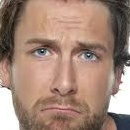

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Veredicto de la IA: happy (Confianza: 42.1%)


In [ ]:
# ============================================================
# SECCIÓN 7 — DEMOSTRACIÓN INTERACTIVA
# Permite subir una imagen desde la computadora local
# y aplicar el pipeline completo de SentIA:
#   1. Detección del rostro con Haar Cascade (OpenCV)
#   2. Recorte y preprocesamiento del rostro detectado
#   3. Clasificación emocional con el modelo entrenado
#   4. Visualización del rostro recortado y la predicción
# ============================================================

from google.colab import files

print("Subí tu foto para que la analice el modelo:")
archivo_subido = files.upload()

for nombre_archivo in archivo_subido.keys():
    # Llamamos a la función que pusimos en la Celda 1
    clasificar_emocion_mejorado(nombre_archivo)